#📌 Extracción

In [2]:
import pandas as pd


In [3]:
url='/content/drive/MyDrive/ONE(Oracle next education)/DATA SCIENCE/python para data science/ETL/TelecomX_Data.json'
df=pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [6]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [14]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [15]:
(df == " ").sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [17]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [18]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.dropna(inplace=True)

In [23]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [24]:
df['Churn'].unique()
df['account.Contract'].unique()
df['account.PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [26]:
df['account.Charges.Monthly'].dtype

dtype('float64')

In [29]:
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

In [30]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [31]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [32]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [33]:
binary_cols = df.select_dtypes(include='object').columns

for col in binary_cols:
    if set(df[col].unique()) == {'Yes', 'No'}:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [34]:
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)

In [35]:
df.rename(columns={
    'customer.gender': 'Genero',
    'customer.tenure': 'Antiguedad',
    'accountCharges.Monthly': 'Cargo_Mensual',
    'accountCharges.Total': 'Cargo_Total'
}, inplace=True)

In [36]:
df.select_dtypes(include='object').columns

Index(['customerID', 'Genero', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaymentMethod'],
      dtype='object')

##Primer insight

In [37]:
df.groupby('account.Contract')['Churn'].mean().sort_values(ascending=False)

,Churn
account.Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


#📊 Carga y análisis

In [40]:
df.describe()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,Antiguedad,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [41]:
df.groupby('Churn').describe()

customer.SeniorCitizen                                               \
                       count      mean       std  min  25%  50%  75%  max   
Churn                                                                       
0.0                   5163.0  0.128995  0.335227  0.0  0.0  0.0  0.0  1.0   
1.0                   1869.0  0.254682  0.435799  0.0  0.0  0.0  1.0  1.0   

      customer.Partner            ... account.Charges.Total           \
                 count      mean  ...                   75%      max   
Churn                             ...                                  
0.0             5163.0  0.527600  ...              4264.125  8672.45   
1.0             1869.0  0.357945  ...              2331.300  8684.80   

      Cuentas_Diarias                                                    
                count      mean       std   min   25%   50%   75%   max  
Churn                                                                    
0.0            5163.0  2.043486  1.036560  0.61  0.84  2.15  2.95  3.96  
1.0            1869.0  2.481450  0.822287  0.63  1.87  2.66  3.14  3.94  

[2 rows x 72 columns]

In [42]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


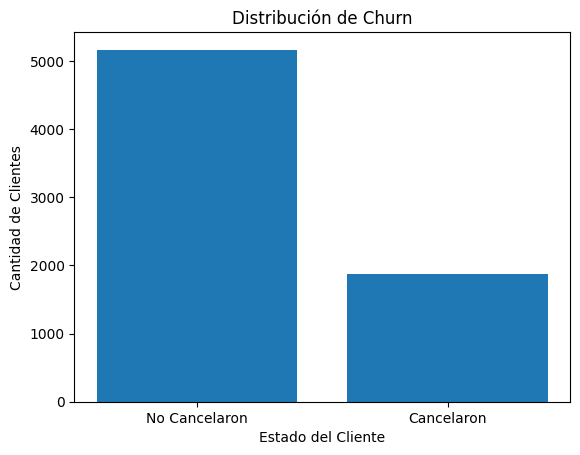

In [43]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure()
plt.bar(['No Cancelaron', 'Cancelaron'], churn_counts)
plt.title('Distribución de Churn')
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [44]:
df.groupby('Genero')['Churn'].mean().sort_values(ascending=False)

,Churn
Genero,
Female,0.269595
Male,0.262046


In [45]:
df.groupby('account.Contract')['Churn'].mean().sort_values(ascending=False)

,Churn
account.Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [46]:
df.groupby('account.PaymentMethod')['Churn'].mean().sort_values(ascending=False)

,Churn
account.PaymentMethod,
Electronic check,0.452854
Mailed check,0.192020
Bank transfer (automatic),0.167315
Credit card (automatic),0.152531


In [47]:
df.groupby('internet.InternetService')['Churn'].mean().sort_values(ascending=False)

,Churn
internet.InternetService,
Fiber optic,0.418928
DSL,0.189983
No,0.074342


In [48]:
df.groupby('customer.SeniorCitizen')['Churn'].mean()

,Churn
customer.SeniorCitizen,
0,0.236503
1,0.416813


In [50]:
df.groupby('Churn')[['Antiguedad',
                     'account.Charges.Monthly',
                     'account.Charges.Total',
                     'Cuentas_Diarias']].mean()

,Antiguedad,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
Churn,,,,
0.0,37.650010,61.307408,2555.344141,2.043486
1.0,17.979133,74.441332,1531.796094,2.481450


<Figure size 640x480 with 0 Axes>

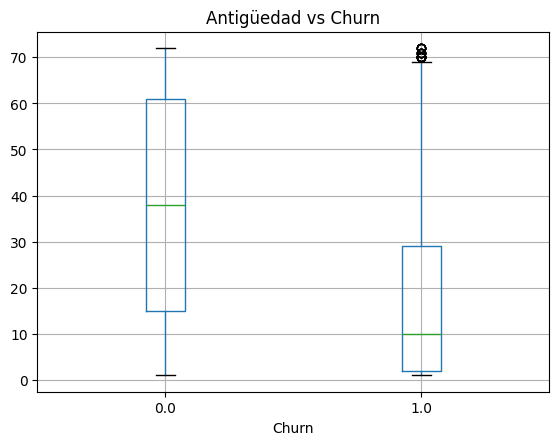

In [51]:
plt.figure()
df.boxplot(column='Antiguedad', by='Churn')
plt.title('Antigüedad vs Churn')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

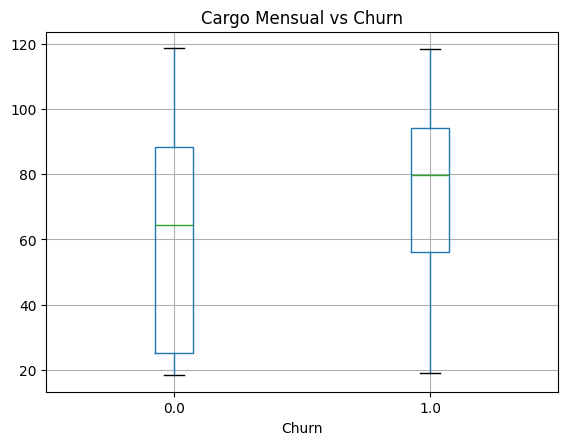

In [53]:
plt.figure()
df.boxplot(column='account.Charges.Monthly', by='Churn')
plt.title('Cargo Mensual vs Churn')
plt.suptitle('')
plt.show()

#📄Informe final

#### 1. Introducción

El objetivo fue analizar los factores que influyen en la evasión de clientes (Churn) en Telecom X, identificando patrones que permitan diseñar estrategias de retención, analizando factores como tipo de contrato, antiguedad y nivel de gasto.

####2. Limpieza y Preparación

Normalización del JSON y aplanamiento de columnas.

Conversión de variables numéricas.

Eliminación de 11 valores nulos.

Transformación de variables binarias (Yes/No → 1/0).

Creación de Cuentas_Diarias = Cargo_Mensual / 30.

El dataset quedó limpio y listo para análisis.

####3. Principales Hallazgos

27% de los clientes cancelan.

Contrato Month-to-month → 42.7% de churn (mayor riesgo).

Clientes con menor antigüedad cancelan más.

Clientes que pagan más mensual/diario presentan mayor evasión.

Adultos mayores muestran mayor tasa de cancelación.

####4. Conclusiones

El churn está fuertemente asociado a:

Tipo de contrato

Antigüedad

Nivel de gasto

Los clientes nuevos con contrato mensual y mayor gasto son el grupo de mayor riesgo.

####5. Recomendaciones

Incentivar contratos anuales.

Implementar estrategias de retención temprana.

Revisar percepción de valor en planes de mayor costo.

Atención diferenciada para clientes senior.